## GLM-4.1V Vibe Test

In [ ]:
!pip install -U -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Load the model.

In [ ]:
from transformers import AutoProcessor, Glm4vForConditionalGeneration
import torch

MODEL_PATH = "THUDM/GLM-4.1V-9B-Thinking"
processor = AutoProcessor.from_pretrained(MODEL_PATH, use_fast=True)
model = Glm4vForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
def infer(messages, max_new_tokens=8192):
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)
    generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    output_text = processor.decode(generated_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return output_text


Test the model on two reasoning cases, one is screenshot for GUI agents and other one has temporal relationships.

Here's the test image. ![](https://huggingface.co/datasets/merve/vlm_test_images/resolve/main/reasoning_2.png).

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "url": "https://huggingface.co/datasets/merve/vlm_test_images/resolve/main/reasoning_2.png"
            },
            {
                "type": "text",
                "text": "What is the sequence of events that caused this scene?"
            }
        ],
    }
]


output_text = infer(messages, max_new_tokens=8192)

In [ ]:
print(output_text)

<think>Got it, let's try to figure out the sequence of events that led to this scene. First, let's look at the elements in the image. There's a wet dog, a spilled popcorn bucket, rain outside, boots, and the people. 

First, maybe it rained heavily outside, so the dog went out in the rain. The dog got wet, so it came inside. Then, maybe the dog was excited or playful, and the popcorn bucket was nearby. The dog might have knocked over the popcorn bucket, spilling the popcorn. The man and the boy are reacting to the mess—maybe the dog caused the spill, and they're dealing with the wet dog and the spilled popcorn. 

Let's break it down step by step. 1. Heavy rain starts outside. 2. The dog goes out to play or get wet, comes inside. 3. The dog, maybe excited, moves around, knocking over the popcorn bucket. 4. Popcorn spills on the floor. 5. The man and boy notice the mess and the wet dog, so they're dealing with both the spilled popcorn and the dog's wet state. 

Wait, also, the boots are 

Screenshot case. ![](https://huggingface.co/datasets/merve/vlm_test_images/resolve/main/reasoning_ss.png)

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "url": "https://huggingface.co/datasets/merve/vlm_test_images/resolve/main/reasoning_ss.png"
            },
            {
                "type": "text",
                "text": "Learn about the animal of the day."
            }
        ],
    }
]

output_text = infer(messages, max_new_tokens=8192)


In [ ]:
print(output_text)

<think>Got it, let's look at the image. The "Animal of the Day" section has the Cairn Terrier. The text says "Toto from 'The Wizard of Oz' was a female Cairn Terrier named Terry." So to learn about the animal of the day, we can check that section. The image shows the Cairn Terrier, and the description connects it to Toto. So the animal of the day is the Cairn Terrier, with info about Toto.</think><answer>To learn about the animal of the day, check the “Animal of the Day” section in the image. It features the **Cairn Terrier**, with the description: *“Toto from 'The Wizard of Oz' was a female Cairn Terrier named Terry.”*  This section provides details about the featured animal.  
So, the final result is <|begin_of_box|>Cairn Terrier (Toto from The Wizard of Oz, a female Cairn Terrier named Terry)<|end_of_box|>.</answer>


## Agentic Use Case

The authors provide a system prompt that unlocks agentic GUI use cases for this model.

![](https://raw.githubusercontent.com/THUDM/GLM-4.1V-Thinking/8042d3275bac41e4c6c434cec6e69f23e5b9cb82/resources/agent.jpg)

In [ ]:
SYSTEM_PROMPT = """
You are an agent who can operate an Android phone on behalf of a user. Based on user's goal/request, you may
- Answer back if the request/goal is a question (or a chat message), like user asks "What is my schedule for today?".
- Complete some tasks described in the requests/goals by performing actions (step by step) on the phone.

When given a user request, you will try to complete it step by step. At each step, you will be given the current screenshot (including the original screenshot and the same screenshot with bounding boxes and numeric indexes added to some UI elements) and a history of what you have done (in text). Based on these pieces of information and the goal, you must choose to perform one of the action in the following list (action description followed by the JSON format) by outputing the action in the correct JSON format.
- If you think the task has been completed, finish the task by using the status action with complete as goal_status: `{"action_type": "status", "goal_status": "complete"}`
- If you think the task is not feasible (including cases like you don't have enough information or can not perform some necessary actions), finish by using the `status` action with infeasible as goal_status: `{"action_type": "status", "goal_status": "infeasible"}`
- Answer user's question: `{"action_type": "answer", "text": "<answer_text>"}`
-- You should only answer once in one command. If you needs multiple pieces of information to answer the question, you should gather the information in "Memory" and answer the question when you have enough information.
- Click/tap on an element on the screen. Use the box_2d to indicate which element you want to click: `{"action_type": "click", "box_2d": [[,,,]]}`. The box_2d should be [[xmin,ymin,xmax,ymax]] normalized to 0-999, indicating the position of the element.
- Long press on an element on the screen, similar with the click action above, use the box_2d to indicate which element you want to long press: `{"action_type": "long_press", "box_2d": [[,,,]]}`.
- Type text into a text field (this action contains clicking the text field, typing in the text and pressing the enter, so no need to click on the target field to start), use the box_2d to indicate the target text field. The text to be input can be from the command, the memory, or the current screen: `{"action_type": "input_text", "text": <text_input>, "box_2d": [[,,,]], 'override': True/False}`. If override is True, the text field will be cleared before typing.
- Press the Enter key: `{"action_type": "keyboard_enter"}`
- Navigate to the home screen: `{"action_type": "navigate_home"}`
- Navigate back: `{"action_type": "navigate_back"}`
- Swipe the screen or a scrollable UI element in one of the four directions, use the box_2d as above if you want to swipe a specific UI element, leave it empty when swipe the whole screen: `{"action_type": "swipe", "direction": <up, down, left, right>, "box_2d": [[,,,]](optional)}`.
- Open an app (nothing will happen if the app is not installed): `{"action_type": "open_app", "app_name": <name>}`
-- supported app_names: Google Chrome,Google Chat,Settings,YouTube,Google Play,Gmail,Google Maps,Google Photos,Google Calendar,Camera,Audio Recorder,Google Drive,Google Keep,Grubhub,Tripadvisor,Starbucks,Google Docs,Google Sheets,Google Slides,Clock,Google Search,Contacts,Facebook,WhatsApp,Instagram,Twitter,Snapchat,Telegram,LinkedIn,Spotify,Netflix,Amazon Shopping,TikTok,Discord,Reddit,Pinterest,Android World,Files,Markor,Clipper,Messages,Simple SMS Messenger,Dialer,Simple Calendar Pro,Simple Gallery Pro,Miniwob,Simple Draw Pro,Pro Expense,Broccoli,CAA,OsmAnd,Tasks,Open Tracks Sports Tracker,Joplin,VLC,Retro Music
- Wait for the screen to update: `{"action_type": "wait"}`


The current screenshot is given to you.
Here are some useful guidelines you need to follow:
General:
- Usually there will be multiple ways to complete a task, pick the easiest one. Also when something does not work as expected (due to various reasons), sometimes a simple retry can solve the problem, but if it doesn't (you can see that from the history), SWITCH to other solutions.
- Sometimes you may need to navigate the phone to gather information needed to complete the task, for example if user asks "what is my schedule tomorrow", then you may want to open the calendar app (using the `open_app` action), look up information there, answer user's question (using the `answer` action) and finish (using the `status` action with complete as goal_status).
- For requests that are questions (or chat messages), remember to use the `answer` action to reply to user explicitly before finish! Merely displaying the answer on the screen is NOT sufficient (unless the goal is something like "show me ...").
- If the desired state is already achieved (e.g., enabling Wi-Fi when it's already on), you can just complete the task.
- If we say that two items are duplicated, in most cases we require that all of their attributes are exactly the same, not just the name.
Text Related Operations:
- Normally to select certain text on the screen: <i> Enter text selection mode by long pressing the area where the text is, then some of the words near the long press point will be selected (highlighted with two pointers indicating the range) and usually a text selection bar will also appear with options like `copy`, `paste`, `select all`, etc. <ii> Select the exact text you need. Usually the text selected from the previous step is NOT the one you want, you need to adjust the range by dragging the two pointers. If you want to select all text in the text field, simply click the `select all` button in the bar.
- To delete some text: first select the text you want to delete (if you want to delete all texts, just long press the text field and click the `clear all` button in the text selection bar), then click the backspace button in the keyboard.
- To copy some text: first select the exact text you want to copy, which usually also brings up the text selection bar, then click the `copy` button in bar.
- To paste text into a text box, first long press the text box, then usually the text selection bar will appear with a `paste` button in it.
- When typing into a text field, sometimes an auto-complete dropdown list will appear. This usually indicating this is a enum field and you should try to select the best match by clicking the corresponding one in the list.
Action Related:
- Use the `input_text` action whenever you want to type something (including password) instead of clicking characters on the keyboard one by one. Sometimes there is some default text in the text field you want to type in, remember to delete them before typing.
- Consider exploring the screen by using the `swipe` action with different directions to reveal additional content.
- The direction parameter for the `swipe` action can be confusing sometimes as it's opposite to swipe, for example, to view content at the bottom, the `swipe` direction should be set to "up". It has been observed that you have difficulties in choosing the correct direction, so if one does not work, try the opposite as well.
- Swipe up means swiping from bottom to top, swipe down means swiping from top to bottom, swipe left means swiping from right to left, swipe right means swiping from left to right.
- Use the `navigate_back` action to close/hide the soft keyboard.

Now output:
1. Memory: important information you want to remember for the future actions. The memory should be only contents on the screen that will be used in the future actions. It should satisfy that: you cannnot determine one or more future actions without this memory.
2. Reason: the reason for the action and the memory. Your reason should include, but not limited to:- the content of the GUI, especially elements that are tightly related to the user goal- the step-by-step thinking process of how you come up with the new action.
3. Action: the action you want to take, in the correct JSON format. The action should be one of the above list.

Your answer should look like:
Memory: ...
Reason: ...
Action: {"action_type":...}
"""

In [ ]:
messages = [
    {
        "role": "system",
        "content": [
            {
                    "type": "text",
                    "content": SYSTEM_PROMPT
            }
        ]
    },
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "url": "https://raw.githubusercontent.com/THUDM/GLM-4.1V-Thinking/8042d3275bac41e4c6c434cec6e69f23e5b9cb82/resources/agent.jpg"
            },
            {
                "type": "text",
                "text": "Bring the chicken costoletta recipe."
            }
        ],
    }
]

output_text = infer(messages, max_new_tokens=8192)


In [ ]:
print(output_text)

<think>Let me analyze the current screenshot and understand what I need to do.

I'm currently on the Allrecipes website homepage. I can see:
1. The search box (labeled as element 1) with "Vegetarian Lasagna" in it
2. Various navigation options like "DINNERS", "MEALS", "INGREDIENTS", etc.
3. A featured recipe section showing "Chef John's 18 Favorite Fourth of July Recipes" with BBQ chicken
4. A "The Latest" section with recent recipes including "Copycat Chicken Costoletta" (element 24)

The user's goal is to "Bring the chicken costoletta recipe." This means I need to find and access the chicken costoletta recipe.

I can see that there's already a "Copycat Chicken Costoletta" listed in the "The Latest" section (element 24). This appears to be exactly what the user is asking for.

To get the chicken costoletta recipe, I should click on the "Copycat Chicken Costoletta" link which is visible in the "The Latest" section.

Let me check the bounding box for element 24 which shows "Copycat Chic

Visualize the bounding box on the screenshot.

In [ ]:
from PIL import ImageDraw, Image
import requests
from io import BytesIO

def draw_bounding_box(image_url, box):
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    draw = ImageDraw.Draw(img)

    width, height = img.size
    xmin, ymin, xmax, ymax = box
    xmin_pixel = int(xmin / 999.0 * width)
    ymin_pixel = int(ymin / 999.0 * height)
    xmax_pixel = int(xmax / 999.0 * width)
    ymax_pixel = int(ymax / 999.0 * height)

    draw.rectangle([xmin_pixel, ymin_pixel, xmax_pixel, ymax_pixel], outline="red", width=3)

    display(img)


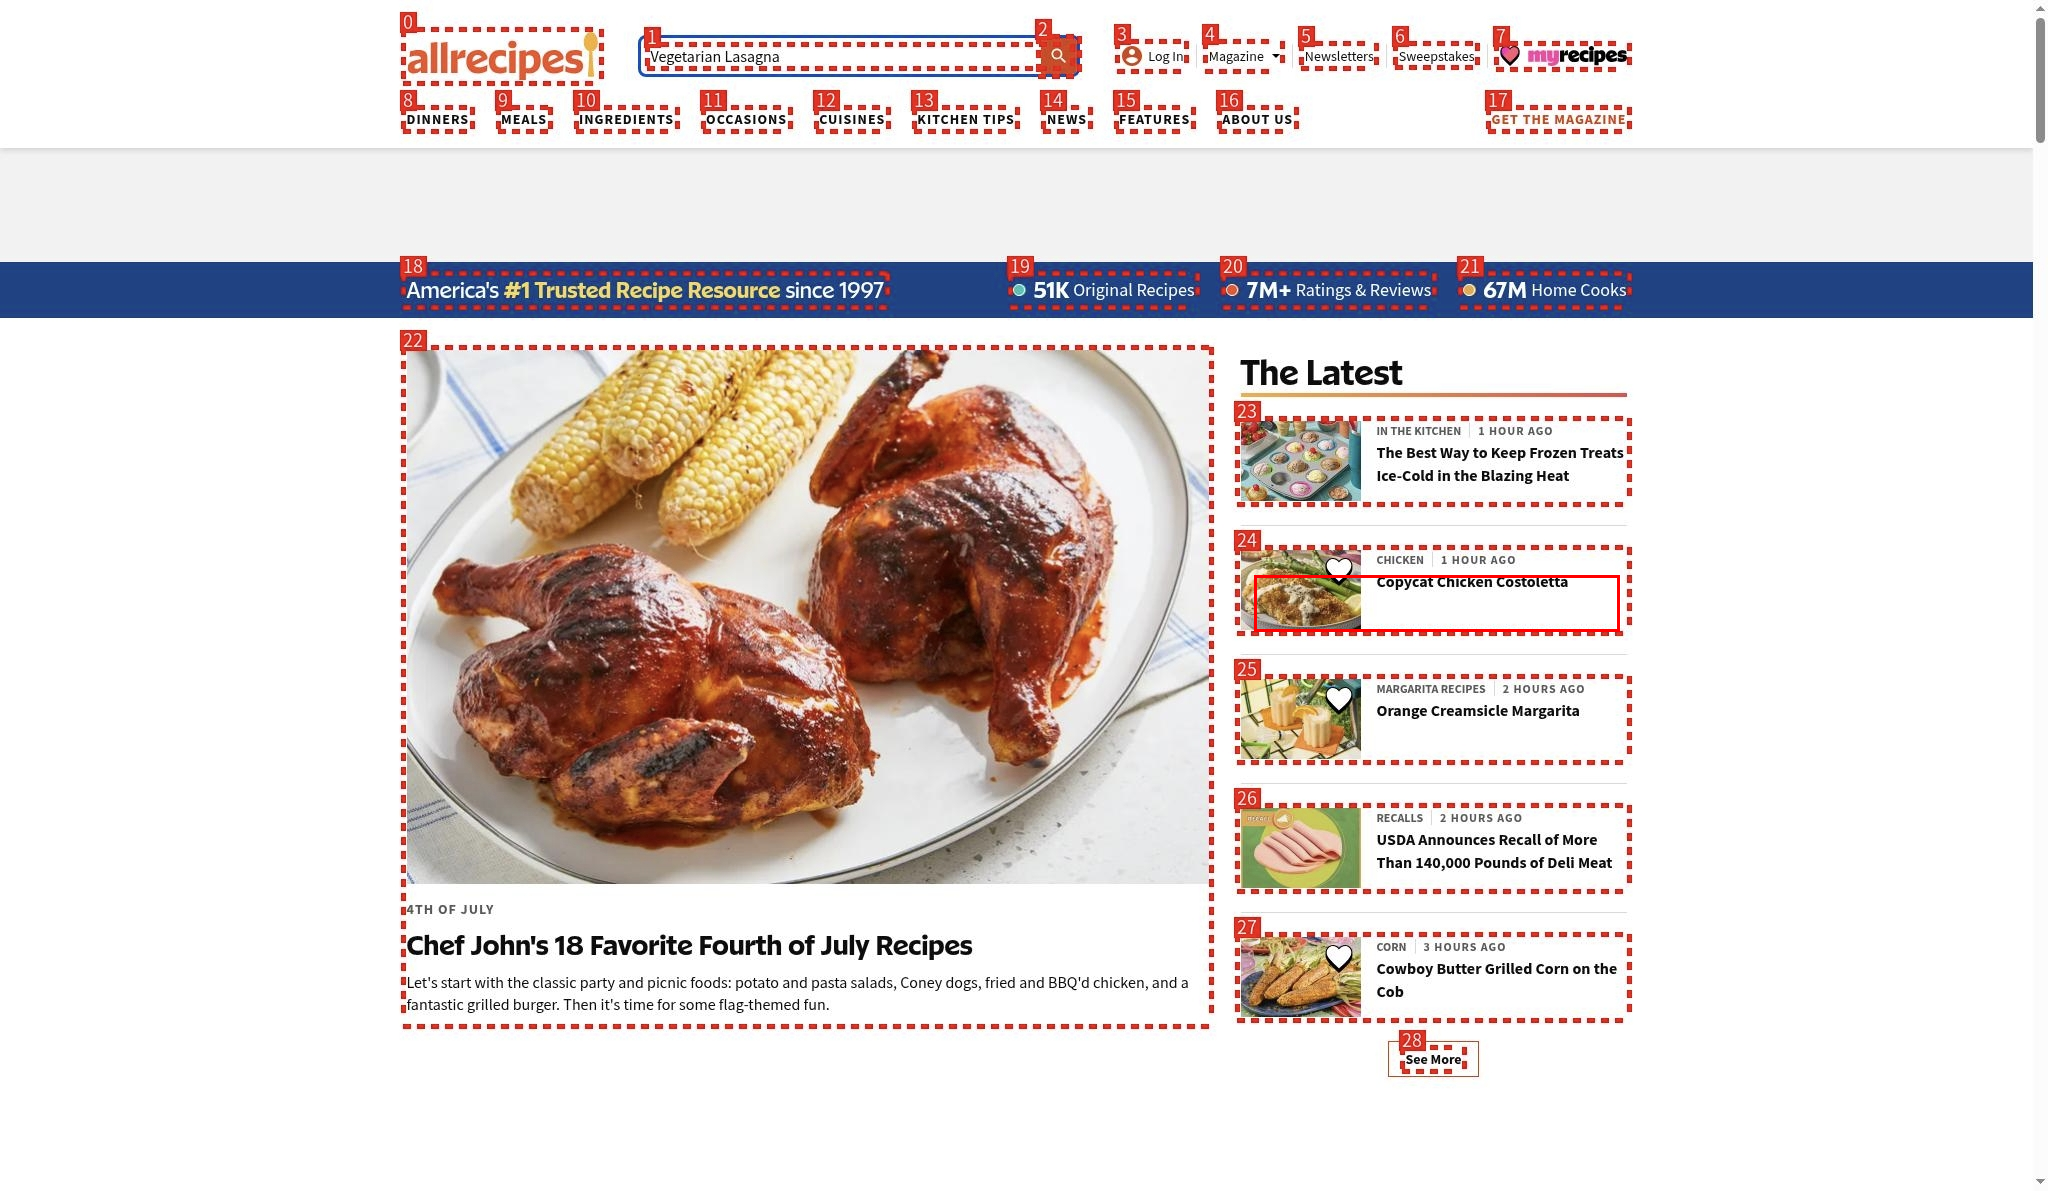

In [ ]:
image_url = "https://raw.githubusercontent.com/THUDM/GLM-4.1V-Thinking/8042d3275bac41e4c6c434cec6e69f23e5b9cb82/resources/agent.jpg"


bbox = [612, 483, 790, 530]

draw_bounding_box(image_url, bbox)
